# UK Forecasting Pipeline

A simplified time series analysis pipeline specific to the UK. Analysis performed as a proof-of-concept and familiarisation with time series forecasting before performing global spatiotemporal forecasting. 

In [1]:
# Import required libraries 
import kagglehub
from pathlib import Path
import math
import calendar
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from pandas import DataFrame
from pandas import concat
from scipy import stats
from scipy.stats import pointbiserialr, f_oneway, chi2_contingency
from statsmodels.stats.multitest import multipletests
from sklearn import metrics
from sklearn.metrics import make_scorer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor

c:\Users\rk1523\Desktop\Projects\weather-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download updated dataset from repository
dataset_handle = "nelgiriyewithana/global-weather-repository"
data_folder = Path("Data-main")

kagglehub.dataset_download(
    dataset_handle,
    output_dir=data_folder,
    force_download=True
)

100%|██████████| 12.0M/12.0M [00:01<00:00, 6.88MB/s]

Extracting files...


WindowsPath('Data-main')

## 1. Basic Data inspection

- Complete dataframe has 151827 samples and 41 features
- Many redundant features e.g. wind_kph and wind_mph
- 778 samples from the UK, all from London

Subsetting for data from the UK,
- 777 unique dates with one repeat on the first sampling date
- This means one sample per day, at various times between 6AM and 3PM
- 6 dates are missing across the complete sampling period. This must be interpolated

In [3]:
# Read data to pandas dataframe
csv_path = list(data_folder.rglob("*.csv"))[0]
df = pd.read_csv(csv_path)

# Inspect data
display(df.head())
print("Dataframe dimensions: ", df.shape)
print("NaN values present: ", df.isna().sum().sum() != 0)
print("Observations in UK: ", sum(df["country"] == "United Kingdom"))
print("Observations in London: ", sum(df["location_name"] == "London"))

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


Dataframe dimensions:  (152022, 41)
NaN values present:  False
Observations in UK:  779
Observations in London:  779


In [4]:
# Subset dataframe to only samples in London
london_df = df[df["country"] == "United Kingdom"].copy()
london_df["last_updated"] = pd.to_datetime(london_df["last_updated"])

# Set index to sampling time and sort 
london_df.set_index("last_updated", inplace=True)
london_df.sort_index(ascending = True, inplace=True)

# Inspect new dataframe
display(london_df.head())
print("Dataframe dimensions: ", london_df.shape)
print("Number of unique dates sampled: ", len(np.unique(london_df.index.date)))

# Check all dates are present
actual_dates = pd.DatetimeIndex(london_df.index.normalize().unique())

expected_dates = pd.date_range(
    start="2024-05-16",
    end=pd.Timestamp.today().normalize(),
    freq="D"
)

missing_dates = expected_dates.difference(actual_dates)

print(f"No missing days: {missing_dates.empty}")
print(f"{len(missing_dates)} Missing days: ", pd.Series(missing_dates.date))

,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
last_updated,,,,,,,,,,,,,,,,,,,,,
2024-05-16 09:45:00,United Kingdom,London,51.52,-0.11,Europe/London,1715849100,14.0,57.2,Partly cloudy,2.5,...,16.9,19.8,2,2,05:07 AM,08:48 PM,01:02 PM,02:57 AM,Waxing Gibbous,55
2024-05-16 15:15:00,United Kingdom,London,51.52,-0.11,Europe/London,1715868900,15.0,59.0,Partly cloudy,6.9,...,2.3,2.7,1,1,05:07 AM,08:48 PM,01:02 PM,02:57 AM,Waxing Gibbous,55
2024-05-17 17:15:00,United Kingdom,London,51.52,-0.11,Europe/London,1715962500,21.0,69.8,Sunny,3.8,...,2.5,2.9,1,1,05:05 AM,08:49 PM,02:12 PM,03:09 AM,Waxing Gibbous,64
2024-05-18 15:30:00,United Kingdom,London,51.52,-0.11,Europe/London,1716042600,18.0,64.4,Partly cloudy,6.9,...,3.3,3.7,1,1,05:04 AM,08:51 PM,03:22 PM,03:19 AM,Waxing Gibbous,73
2024-05-19 15:15:00,United Kingdom,London,51.52,-0.11,Europe/London,1716128100,22.0,71.6,Partly cloudy,9.4,...,6.8,8.0,1,1,05:02 AM,08:52 PM,04:32 PM,03:28 AM,Waxing Gibbous,81


Dataframe dimensions:  (779, 40)
Number of unique dates sampled:  778
No missing days: False
6 Missing days:  0    2024-06-18
1    2024-07-13
2    2024-07-21
3    2024-07-22
4    2026-01-19
5    2026-03-09
dtype: object


## 2. Data Filtering and Engineering

Redundant features removed:
- Geographical features (e.g. country, timezone, latitude), since these are constant across samples
- Features differing only by unit (e.g wind_mph, temperature_farenheight) as these will be perfectfly correlated
- Leakage features (e.g. feels_like_celsius), as this contains information about temeperature, which is the predictive outcome
- Air quality features (e.g. air_quality_us-epa-index), as this is a combination of the other air quality particulate features
- Moon-specific features, as this is unlikely to largely affect climate

### Modified time features:
- last_updated
- sunrise
- sunset

modified to: 
- last_updated (in datetime)
- hour_sin
- hour_cos
- day_sin
- day_cos
- sunrise (as numerical)
- sunset (as numerical)

This encodes the most relevant features for temperature prediction. The hours of day in sin and cos represent the cyclical nature of the 24 hour clock and ensure that 23:59 and 0:01 are proximally encoded. This is the same with day sin and day cos. 

### Modified wind features: 
- wind_kph
- wind_direction
- wind_degree

modified to: 
- wind_x
- wind_y

Encodes all information about wind speed and degree in one vector, also capturing the cyclical nature of the degree feature. Wind direction is categorical and redundant and is hence removed. 

In [5]:
# Redundant features removed
features_to_remove = ['country', 'location_name', 'latitude', 'longitude', 'timezone',
                     'last_updated_epoch',
                     'temperature_fahrenheit',
                     'condition_text',
                     'wind_mph','wind_direction',
                     'pressure_in', 'precip_in',
                     'feels_like_celsius','feels_like_fahrenheit',
                     'visibility_miles',
                     'gust_mph',
                     'air_quality_us-epa-index', 'air_quality_gb-defra-index', 
                     'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

london_df.drop(columns = features_to_remove, inplace=True)


In [6]:
# Create cyclical sin and cos components for time of day and day of year
# Cyclical encoding removes artificial boundaries e.g. between 23:59/0:01 and 31-Dec/1-Jan
# Also keep numerical time_of_day and day_of_year for later visualisation
def create_time_series(df):
    try: 
        date = df.index
        day_of_year = date.dayofyear
        annual_progress = (day_of_year - 1) / np.where(date.is_leap_year, 366, 365)
        day_angle = 2 * np.pi * annual_progress
        
        time_of_day = (
            date.hour
            + date.minute / 60
            + date.second / 3600)
        daily_progress = time_of_day / 24
        time_angle = 2 * np.pi * daily_progress

        df = df.assign(
            day_sin=np.sin(day_angle),
            day_cos=np.cos(day_angle),
            time_sin=np.sin(time_angle),
            time_cos=np.cos(time_angle),
            day_of_year = day_of_year,
            time_of_day = time_of_day,
            )

        return df
    except AttributeError:
        print("AttributeError: index not in datetime")

# Convert sunrise and sunset from string to time of day
def convert_sun_phase(df):
    for phase in ["sunrise", "sunset"]:

        phase_time = pd.to_datetime(
            df[phase],
            format="%I:%M %p",
            errors="coerce"
            )
        
        df[phase] = phase_time.dt.hour + phase_time.dt.minute / 60
    return df

# Convert wind speed + degree into x and y components
# Keep original values for visualisation
def decompose_wind(df):
    wind_rad = np.radians(df["wind_degree"])

    # Meteorological convention:
    # wind_degree = direction wind comes FROM
    df["wind_x"] = -df["wind_kph"] * np.sin(wind_rad)  # east-west component
    df["wind_y"] = -df["wind_kph"] * np.cos(wind_rad)  # north-south component

    return df

# Create pipe for applying all feature engineering functions
def pipe(value, *funcs):
    for func in funcs:
        value = func(value)
    return value

london_df = pipe(london_df, create_time_series, convert_sun_phase, decompose_wind)

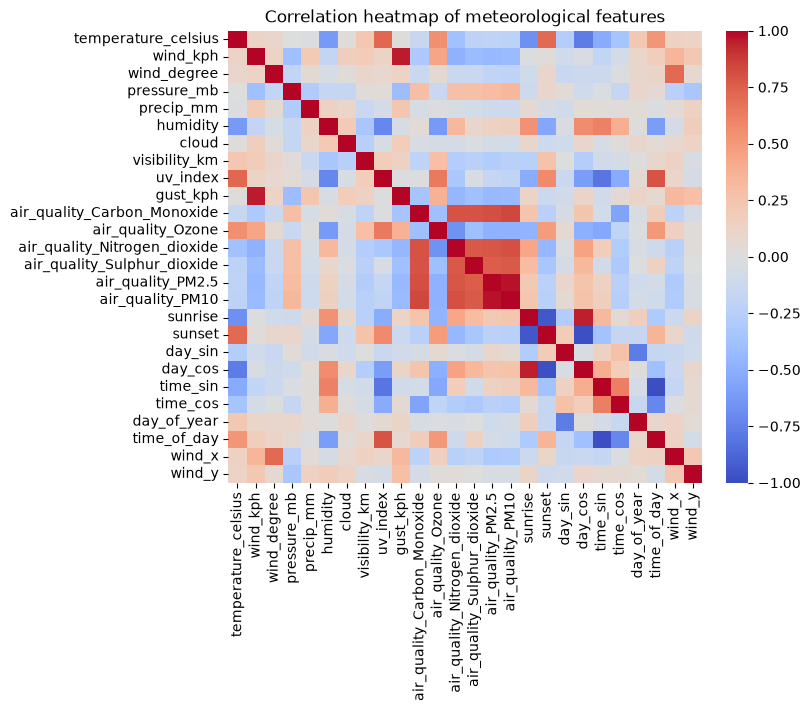

Pearson's correlation between gust and wind:  0.9542668207997691
Pearson's correlation between air quality PM2.5 and PM10:  0.9703423892821802


In [7]:
# Check for strong correlation between features
corr = london_df.corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 7), layout="constrained")

sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False
)

ax.set_title("Correlation heatmap of meteorological features")
plt.show()

# gust_kph and wind_kph are strongly correlated
# air_quality_PM2.5 and air_quality_PM10 are strongly correlated
print("Pearson's correlation between gust and wind: ", corr.loc["gust_kph", "wind_kph"])
print("Pearson's correlation between air quality PM2.5 and PM10: ", corr.loc["air_quality_PM2.5", "air_quality_PM10"])

# Remove highly correlated features
london_df.drop(columns=["gust_kph", "air_quality_PM10"], inplace=True)

## 3. Exploratory Data Analysis

Main analyses: 
1. **Time series plots of climate features**: visualisation of seasonal trends
2. **Boxplot of daily sampling time**: visualisation of sampling time distribution
3. **PCA coloured for each feature**: confirmation whether data separates based on each feature
4. **Outlier detection using Hotelling's T2**: check for outliers and visualise on PCA
5. **Outlier visualisation on time graph**: check validity of outliers against feature data

Results: 
- Temperature and precipitation visualisations show visible seasonal trends: 
    - Temperature lowest in winter months, highest in summer months
    - More extreme rainfall events in autumn to winter, from August to February
    - **However**: limitations in scope of data, only 1 full year cycle recorded
- Boxplot shows 3 distinct sampling clusters around 7AM, 10AM and 2PM
    - Plotting this as a line graph, we see sampling becoming earlier across the timeframe
    - Not ideal as we would want either consistent sampling at the same time each day or at multiple point each day
- PCA colouring shows good separation of data in key features: 
    - Clearest separtation visible in temperature, humidity and UV index
    - Separation by seasonal/daily trends also visible in sunrise/sunset and time_of_day/hour_of_day
    - Suggests forecasting for temperature/humidity/UV is most likely to be successful
- Outliers are visually confirmed as being located towards the periphery of PCA cluster
- Outliers are typically extreme weather events, e.g. extreme rainfall, as confirmed by line graphs
    - We will not be removing these outliers as they are likely anomalous weather events rather than statistical artefacts from data collection 

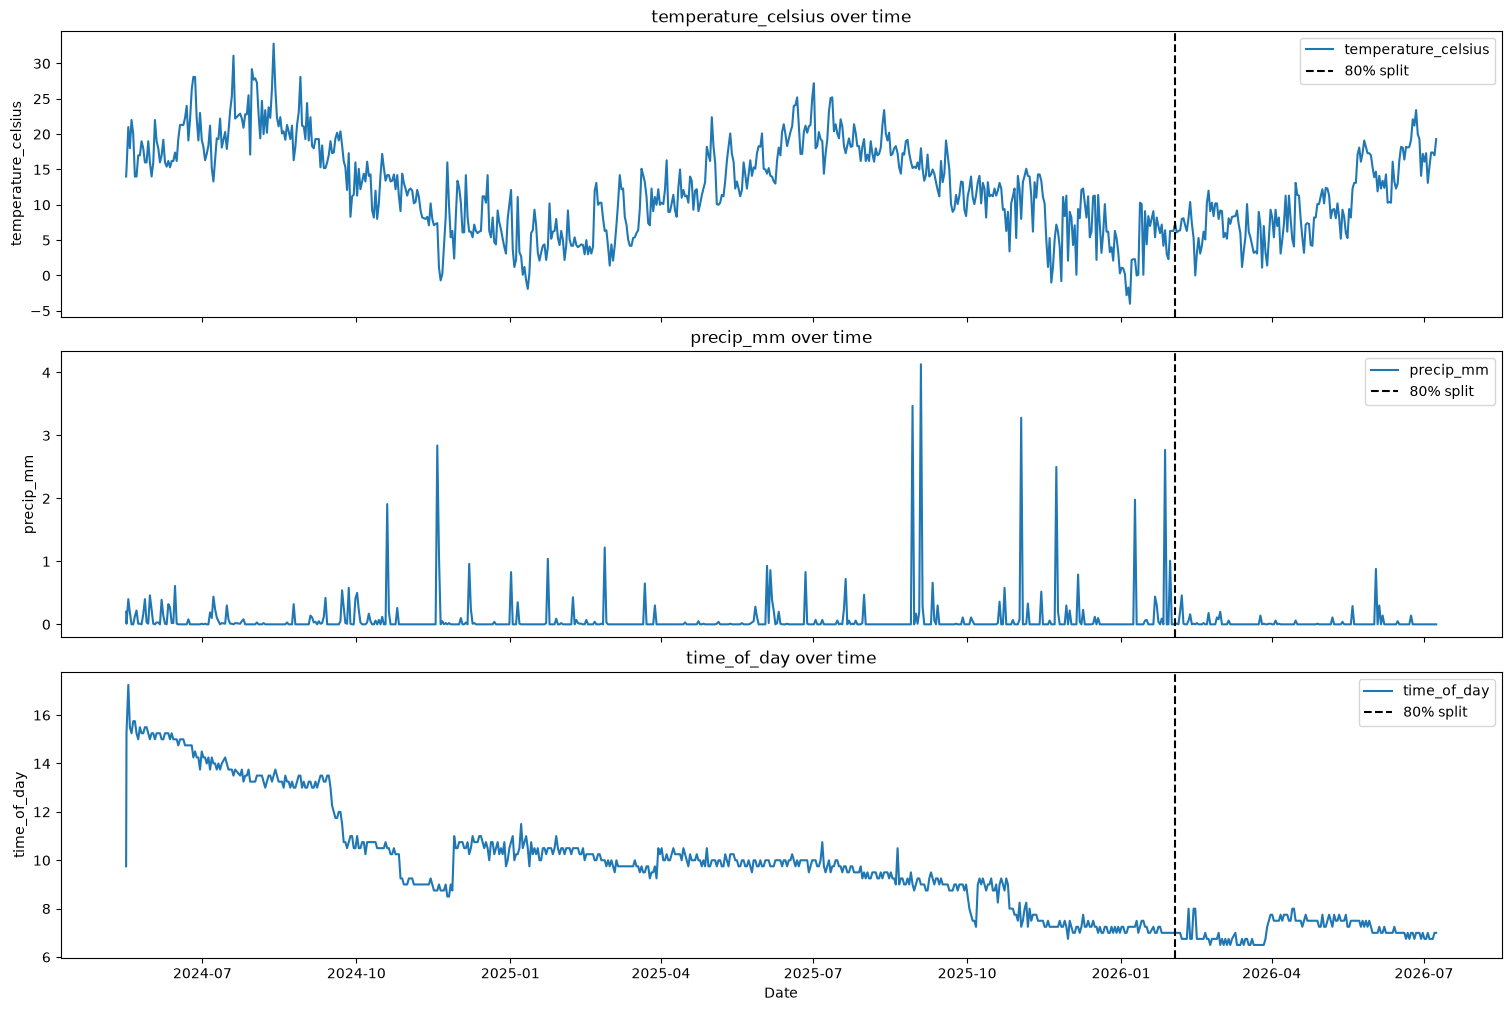

In [8]:
# Features to visualise
features = ["temperature_celsius", "precip_mm", "time_of_day"]

# Identify 80/20 split
split = int(london_df.shape[0] * 0.8)
split_date = london_df.index[split]

# Plot time graph for each feature
fig, axes = plt.subplots(
    nrows=len(features),
    ncols=1,
    figsize=(15, 10),
    layout="constrained",
    sharex=True
)

for ax, feature in zip(axes, features):

    ax.plot(
        london_df.index,
        london_df[feature],
        label=feature
    )

    ax.axvline(
        split_date,
        color="black",
        linestyle="--",
        label="80% split"
    )

    ax.set_ylabel(feature)
    ax.set_title(f"{feature} over time")
    ax.legend()

axes[-1].set_xlabel("Date")

plt.show()

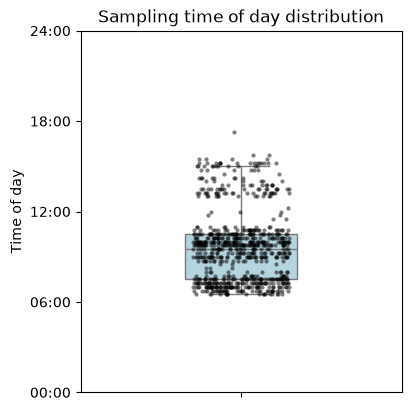

In [9]:
# Plot boxplot of sampling times on each day
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")

sns.boxplot(
    y=london_df["time_of_day"],
    ax=ax,
    color="lightblue",
    width=0.35,
    showfliers=False
)

sns.stripplot(
    y=london_df["time_of_day"],
    ax=ax,
    color="black",
    size=3,
    alpha=0.5,
    jitter=0.15
)

ax.set_ylabel("Time of day")
ax.set_title("Sampling time of day distribution")

ax.set_yticks([0, 6, 12, 18, 24])
ax.set_yticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

plt.show()

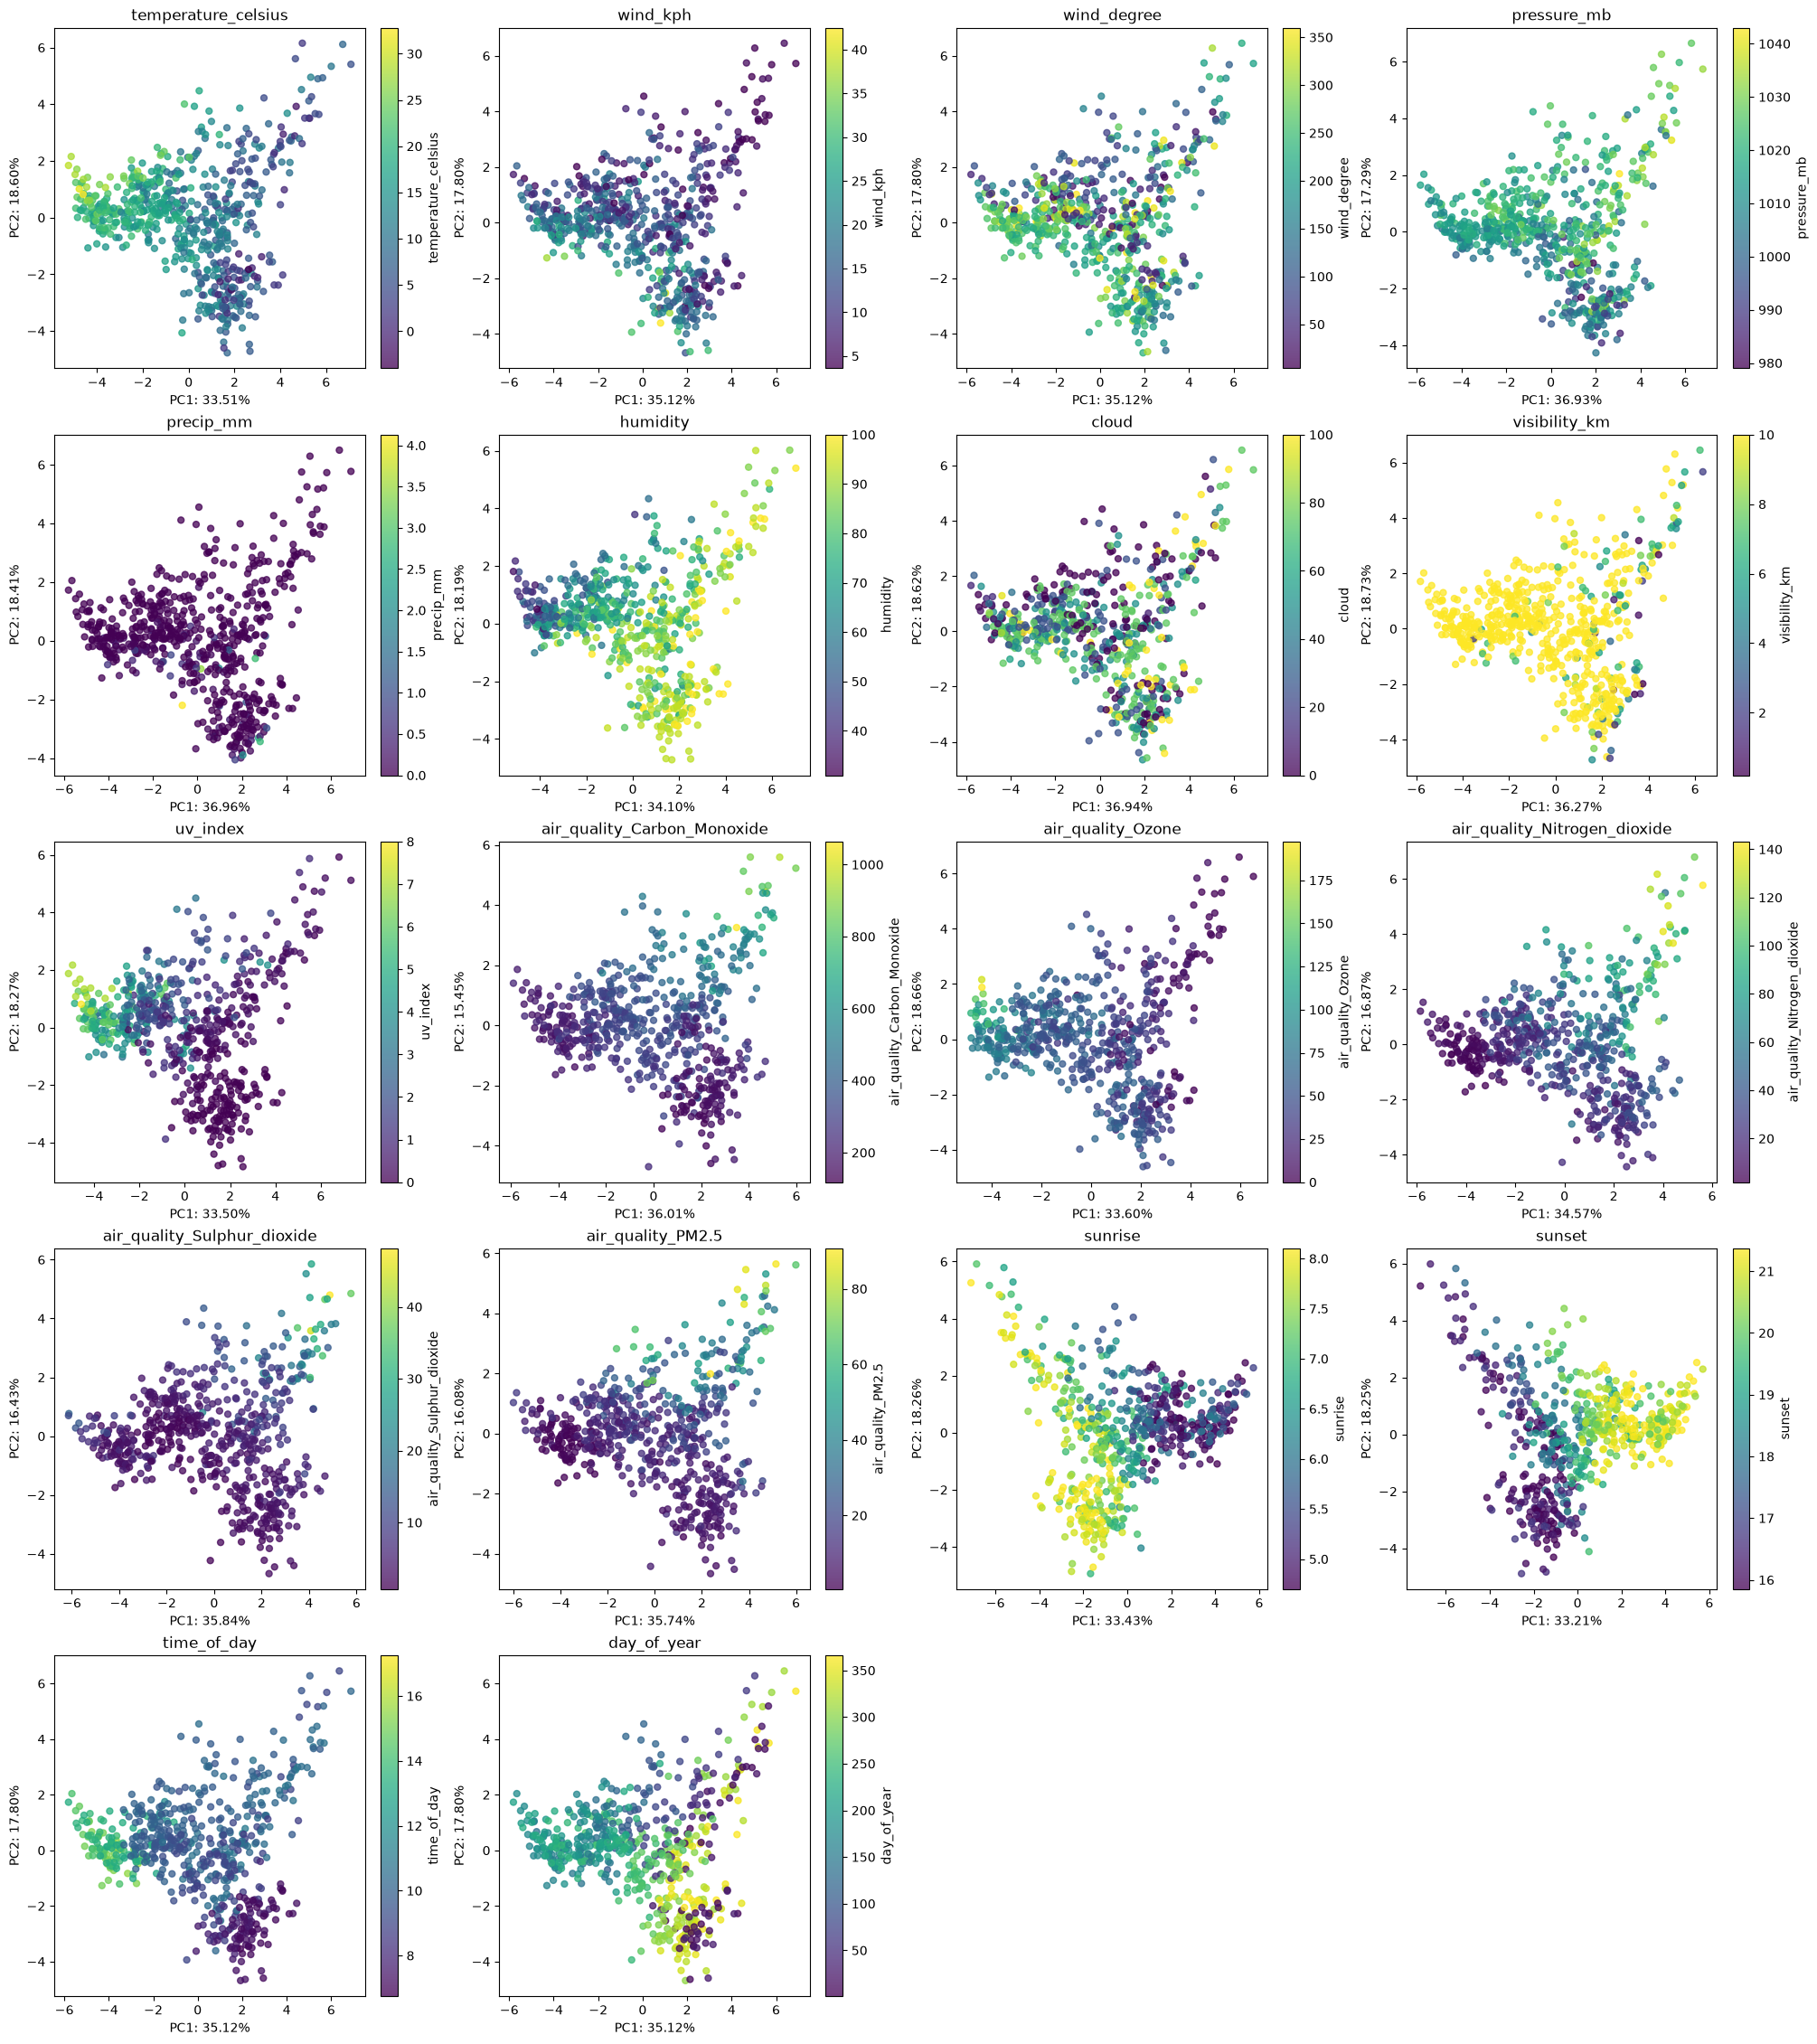

In [10]:
# Plot PCA, excluding each feature and colour labelling
# This shows how well the feature of interest is represented by the other features 

# Take only training set
# This is important for outlier detection and removal
split = int(london_df.shape[0]*0.8)
train_df = london_df.iloc[:split,].copy()

# Create feature list
# Original features for wind, time and day are used as they are more visually informative
feature_list = ['temperature_celsius', 'wind_kph', 'wind_degree', 'pressure_mb',
       'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'sunrise', 'sunset','time_of_day','day_of_year']

# Create grid for PCA plots 
ncols = 4
nrows = math.ceil(len(feature_list) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4.5 * nrows),
    layout="constrained"
)

axes = axes.ravel()

for ax, feature in zip(axes, feature_list):

    # Drop the feature being used as colour, plus non-cyclical time/wind variables if present
    X_train = train_df.drop(columns=set([feature, 'wind_kph', 'wind_degree', "time_of_day", "day_of_year"]))
    y_train = train_df[feature].values

    # Scale (necessary for PCA)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    pca = PCA(n_components=5)
    pca_data = pca.fit_transform(X_train_scaled)

    pvars = pca.explained_variance_ratio_[:2] * 100

    scatter = ax.scatter(
        pca_data[:, 0],
        pca_data[:, 1],
        c=y_train,
        cmap="viridis",
        alpha=0.75,
        s=25
    )

    ax.set_title(feature)
    ax.set_xlabel(f"PC1: {pvars[0]:.2f}%")
    ax.set_ylabel(f"PC2: {pvars[1]:.2f}%")

    fig.colorbar(scatter, ax=ax, label=feature)

# Hide unused axes if grid has empty spaces
for ax in axes[len(feature_list):]:
    ax.set_visible(False)

plt.show()


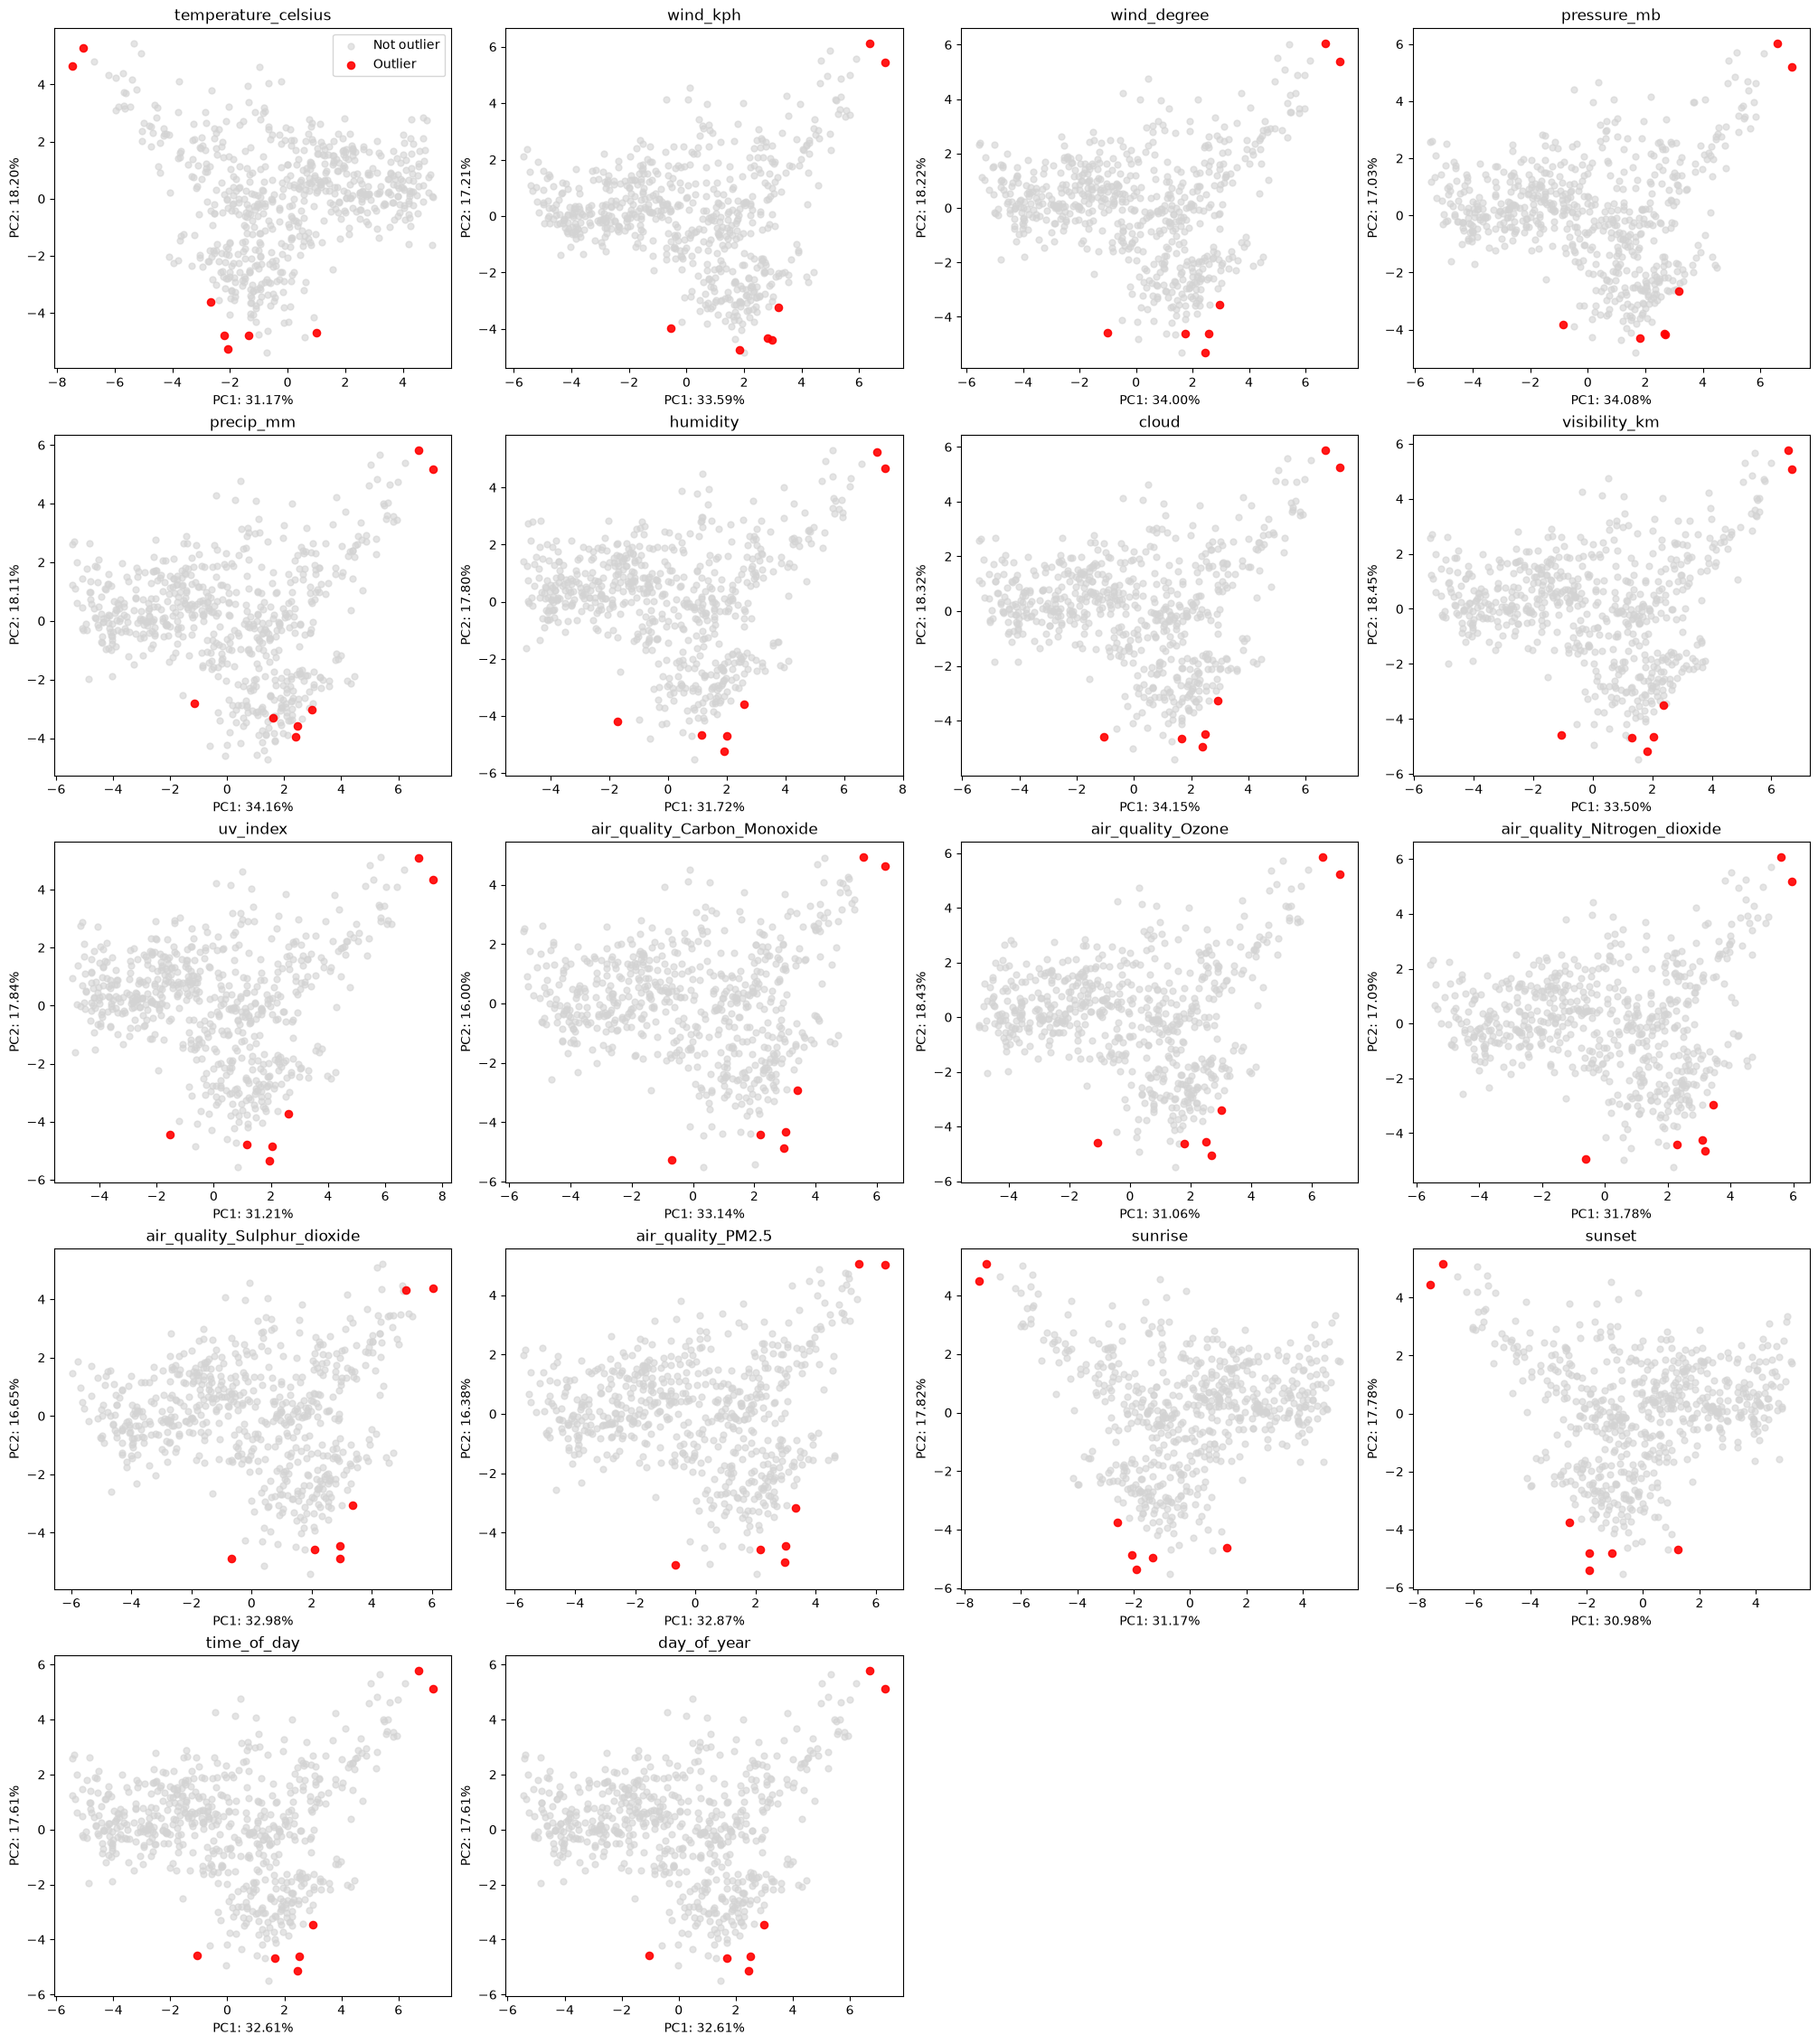

In [11]:
# Create outlier detection function, using the training dataframe and multiple testing correction
# Outlier funciton is performed on the complete dataframe and visualised on each separate PCA plot
def find_outliers(train_df, alpha=0.05, n_components=5):

    X_train = train_df.drop(columns=['wind_kph', 'wind_degree', "time_of_day", "day_of_year"])

    X_train_scaled = StandardScaler().fit_transform(X_train)

    pca_data = PCA(n_components=n_components).fit_transform(X_train_scaled)

    n = pca_data.shape[0]
    p = pca_data.shape[1]

    cov_matrix = np.cov(pca_data, rowvar=False)
    inv_cov = np.linalg.pinv(cov_matrix)

    T2 = np.array([
        pca_data[i, :] @ inv_cov @ pca_data[i, :].T
        for i in range(n)
    ])

    p_values = 1 - stats.chi2.cdf(T2, df=p)

    outlier, p_values_bh, _, _ = multipletests(
        p_values,
        alpha=alpha,
        method="fdr_bh"
    )

    return outlier

# Plot PCAs and colour with outliers
ncols = 4
nrows = math.ceil(len(feature_list) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4.5 * nrows),
    layout="constrained"
)

axes = axes.ravel()
outlier = find_outliers(train_df)

for ax, feature in zip(axes, feature_list):

    # Drop the feature being used as colour, plus time variables if present
    X_train = train_df.drop(columns=set([feature, "time_of_day", "day_of_year"]))

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    pca = PCA(n_components=5)
    pca_data = pca.fit_transform(X_train_scaled)

    pvars = pca.explained_variance_ratio_[:2] * 100

    # Non-outliers: grey
    ax.scatter(
        pca_data[~outlier, 0],
        pca_data[~outlier, 1],
        color="lightgrey",
        alpha=0.6,
        s=25,
        label="Not outlier"
    )

    # Outliers: red
    ax.scatter(
        pca_data[outlier, 0],
        pca_data[outlier, 1],
        color="red",
        alpha=0.9,
        s=35,
        label="Outlier"
    )

    ax.set_title(feature)
    ax.set_xlabel(f"PC1: {pvars[0]:.2f}%")
    ax.set_ylabel(f"PC2: {pvars[1]:.2f}%")
    if ax == axes[0]:
        ax.legend()

# Hide unused axes if grid has empty spaces
for ax in axes[len(feature_list):]:
    ax.set_visible(False)

plt.show()

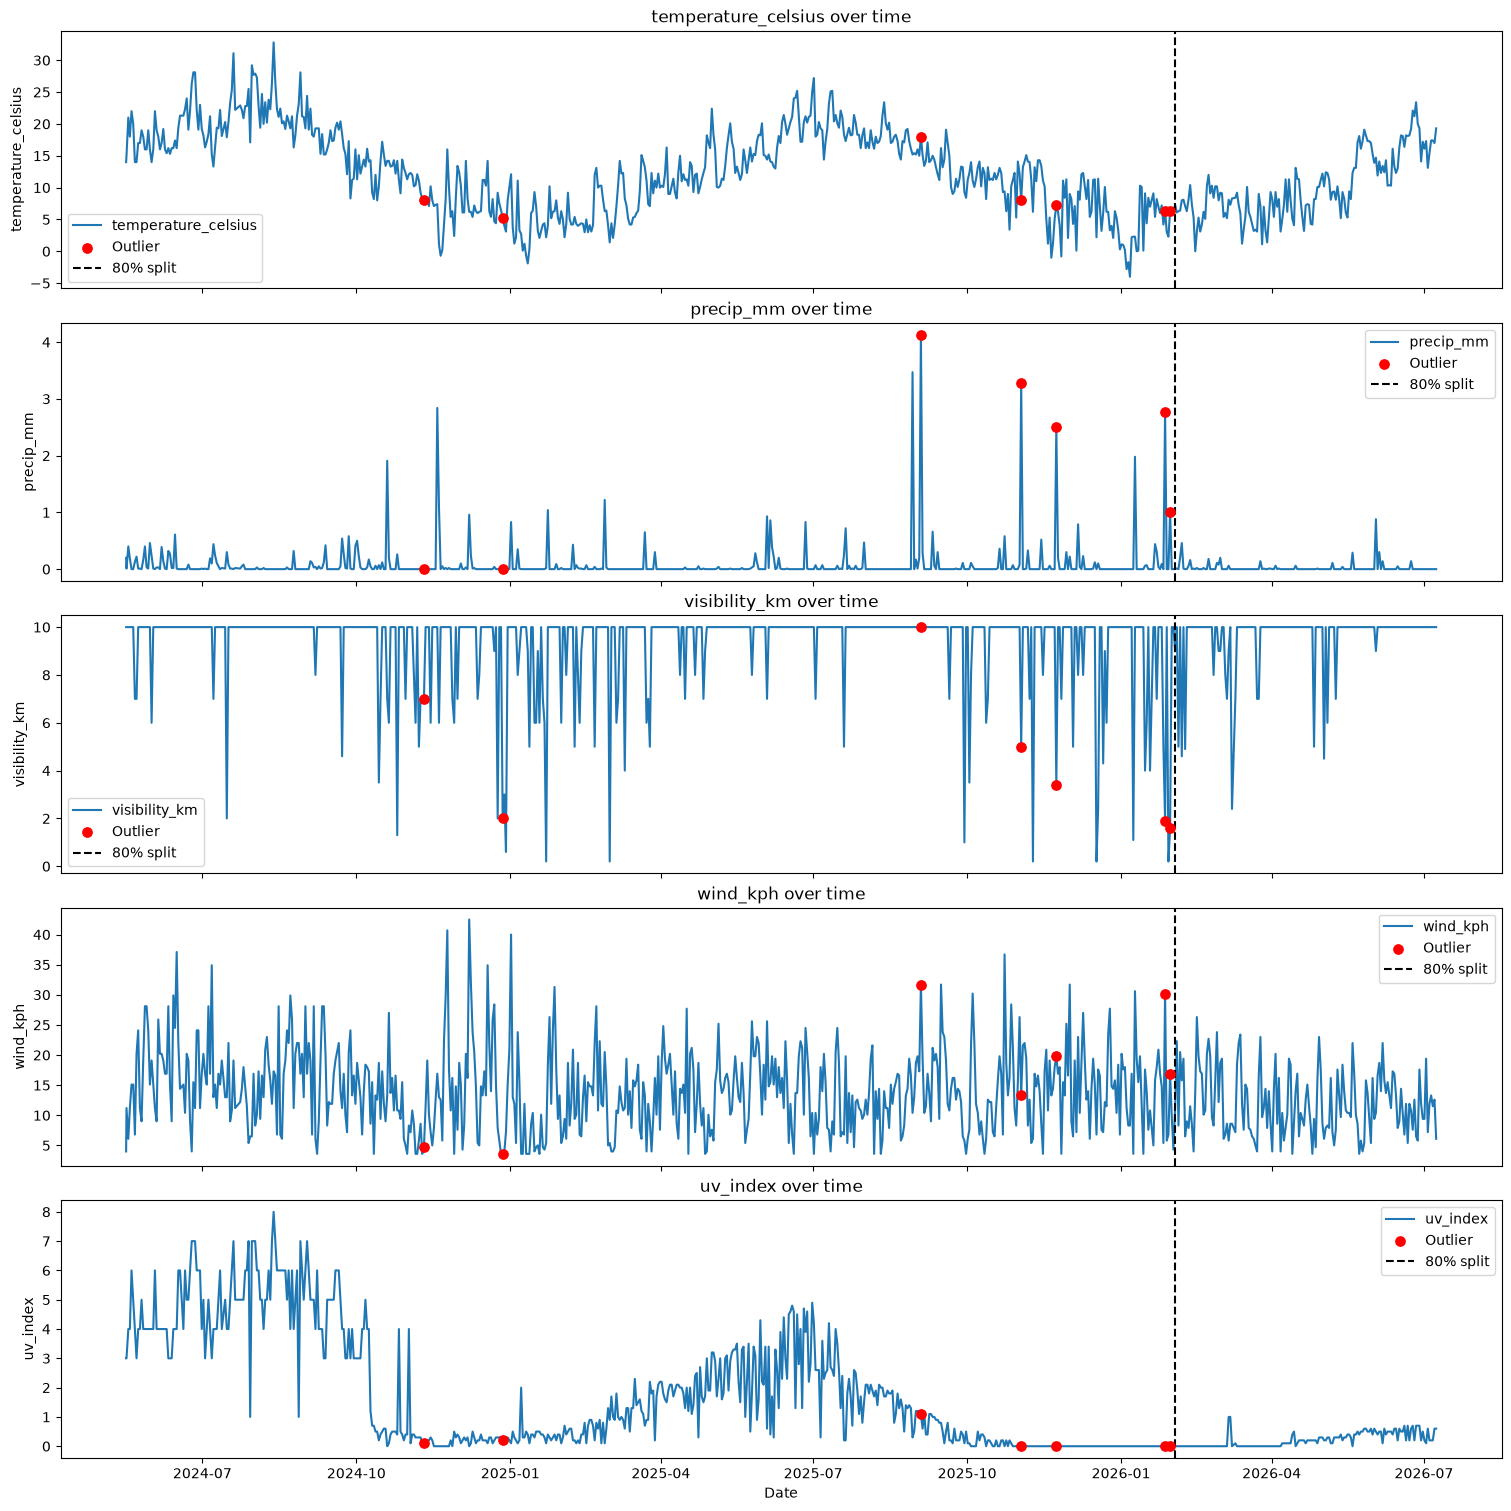

In [12]:
# Plot outliers on time series visualisations
features = ["temperature_celsius", "precip_mm", "visibility_km", "wind_kph", "uv_index"]

split = int(london_df.shape[0] * 0.8)
split_date = london_df.index[split]

fig, axes = plt.subplots(
    nrows=len(features),
    ncols=1,
    figsize=(15, 15),
    layout="constrained",
    sharex=True
)

for ax, feature in zip(axes, features):

    ax.plot(
        london_df.index,
        london_df[feature],
        label=feature
    )

    ax.scatter(
        train_df.index[outlier],
        train_df.loc[outlier, feature],
        color="red",
        s=45,
        zorder=3,
        label="Outlier"
    )

    ax.axvline(
        split_date,
        color="black",
        linestyle="--",
        label="80% split"
    )

    ax.set_ylabel(feature)
    ax.set_title(f"{feature} over time")
    ax.legend()

axes[-1].set_xlabel("Date")

plt.show()

## 4. Multivariate time series forecasting

To forecast future weather trends (namely temperature), we must frame this problem around that of a multivariate time series. Although we are interested in forecasting temperature as the primary feature of interest, there are 19 more variables that carry information to help the prediction (as shown in the PCA). 

Time series forecasting methods and challenges:
- Traditional statistical models (e.g. ARIMA, SARIMAX)
    - Handles univariate time series, requires data to be stationary
- Variance autoregression (e.g VAR)
    - Can perform multivariate time series, but same data requirements as ARIMA
- Supervised machine learning models (e.g. XGBoost)
    - Can handle multivariate time series and learn seasonality in data
- Neural networds (e.g. LSTM)
    - Long-term memory can also capture signals from earlier timepoints

Therefore, we will trial XGBoost and LSTM for the London weather forecasting data.

In [13]:
# Since there are only 6 missing dates out of 784 days, we will use a simple forward fill strategy

# Create a daily date index covering the full range
full_date_index = pd.date_range(
    start=london_df.index.min().normalize(),
    end=london_df.index.max().normalize(),
    freq="D"
)

# Convert to daily data first
forecast_df = london_df.resample("D").mean()

# Add any missing dates, then forward fill
forecast_df = forecast_df.reindex(full_date_index)
forecast_df = forecast_df.ffill()

# Drop features used only for visualisation
forecast_df.drop(columns=["wind_kph","wind_degree","day_of_year","time_of_day"], inplace=True)

# Check that the previously missing dates are now present
print("All missing dates imputed: ", all(date in forecast_df.index for date in missing_dates))
print(f"Forecasting dataframe dimensions: {forecast_df.shape}")

All missing dates imputed:  True
Forecasting dataframe dimensions: (784, 20)


We will use a series to supervised function by Jason Browlee (https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/)

In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	"""
	Frame a time series as a supervised learning dataset.
	Arguments:
		data: Sequence of observations as a list or NumPy array.
		n_in: Number of lag observations as input (X).
		n_out: Number of observations as output (y).
		dropnan: Boolean whether or not to drop rows with NaN values.
	Returns:
		Pandas DataFrame of series framed for supervised learning.
	"""
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

# Confirm correct transformation for a 14 day sliding window
X = series_to_supervised(forecast_df, n_in=14, n_out=1)
print(f"Shifted dataframe dimensions: {X.shape}")
display(X.head())

Shifted dataframe dimensions: (770, 300)


,var1(t-14),var2(t-14),var3(t-14),var4(t-14),var5(t-14),var6(t-14),var7(t-14),var8(t-14),var9(t-14),var10(t-14),...,var11(t),var12(t),var13(t),var14(t),var15(t),var16(t),var17(t),var18(t),var19(t),var20(t)
2024-05-30,14.5,1005.0,0.105,82.5,50.0,10.0,3.0,295.45,34.25,23.3,...,1.7,0.9,4.833333,21.116667,0.536696,-0.843776,-0.707107,-0.707107,2.622087e+00,-14.870597
2024-05-31,21.0,1010.0,0.400,43.0,0.0,10.0,4.0,207.00,75.10,19.4,...,2.1,1.0,4.816667,21.133333,0.522133,-0.852864,-0.751840,-0.659346,4.678151e-15,-19.100000
2024-06-01,18.0,1013.0,0.190,68.0,50.0,10.0,4.0,203.60,86.60,6.7,...,1.4,1.7,4.800000,21.150000,0.507415,-0.861702,-0.751840,-0.659346,3.698433e-15,-15.100000
2024-06-02,22.0,1014.0,0.000,46.0,50.0,10.0,6.0,193.60,120.20,3.1,...,2.9,3.5,4.800000,21.166667,0.492548,-0.870285,-0.707107,-0.707107,5.600000e+00,-9.699485
2024-06-03,20.0,1012.0,0.000,40.0,25.0,10.0,5.0,191.90,107.30,3.9,...,3.8,2.0,4.783333,21.183333,0.477536,-0.878612,-0.751840,-0.659346,7.794229e+00,-4.500000


In [ ]:
# Regressor metrics calculator
def RegmodelPerformance(y_true, y_pred):
    exp_var = metrics.explained_variance_score(y_true, y_pred)
    r_square = metrics.r2_score(y_true, y_pred)
    MSE = metrics.mean_squared_error(y_true, y_pred)
    RMSE = np.sqrt(MSE)
    MAE = metrics.mean_absolute_error(y_true, y_pred)
    return(exp_var, r_square, MSE, RMSE, MAE)

In [ ]:
n_in_values = [7, 14, 30, 60]
cv_results = []

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

tscv = TimeSeriesSplit(n_splits=5)

test_start_date = forecast_df.iloc[int(forecast_df.shape[0] * 0.8)].name

for n_in in n_in_values:
    X = series_to_supervised(forecast_df, n_in=n_in, n_out=1)

    y = forecast_df["temperature_celsius"].shift(-1)
    y = y.loc[X.index]

    valid_idx = y.dropna().index

    X = X.loc[valid_idx]
    y = y.loc[valid_idx]

    X_train = X.loc[X.index < test_start_date]
    y_train = y.loc[y.index < test_start_date]

    xgb = GridSearchCV(
        estimator=XGBRegressor(random_state=42, n_jobs=1),
        param_grid=param_grid,
        cv=tscv,
        scoring="neg_mean_squared_error",
        n_jobs=4
    )

    xgb.fit(X_train, y_train)

    cv_results.append({
        "n_in": n_in,
        "cv_mse": -xgb.best_score_,
        "cv_rmse": np.sqrt(-xgb.best_score_),
        "best_params": xgb.best_params_,
        "grid_search": xgb,
        "train_samplesize": len(X_train),
        "test_samplesize": (len(X) - len(X_train))
        })

results_df = pd.DataFrame(cv_results)
display(results_df)

best_idx = results_df["cv_mse"].idxmin()

best_n_in = results_df.loc[best_idx, "n_in"]
best_params = results_df.loc[best_idx, "best_params"]

print("Best n_in:", best_n_in)
print("Best params:", best_params)

,n_in,cv_mse,cv_rmse,best_params,best_estimator,train_samplesize,test_samplesize
0,7,39.289030,6.268096,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...","XGBRegressor(base_score=None, booster=None, ca...",620,156
1,14,26.223606,5.120899,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...","XGBRegressor(base_score=None, booster=None, ca...",613,156
2,30,21.455928,4.632054,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...","XGBRegressor(base_score=None, booster=None, ca...",597,156
3,60,24.262408,4.925689,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...","XGBRegressor(base_score=None, booster=None, ca...",567,156


Best n_in: 30
Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}


In [36]:
X = series_to_supervised(forecast_df, n_in=best_n_in, n_out=1)

y = forecast_df["temperature_celsius"].shift(-1)
y = y.loc[X.index]

valid_idx = y.dropna().index

X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Train/test split
X_train = X.loc[X.index < test_start_date]
y_train = y.loc[y.index < test_start_date]

X_test = X.loc[X.index >= test_start_date]
y_test = y.loc[y.index >= test_start_date]

# Test classifier on test set
xgb_best = XGBRegressor(
    random_state=42,
    n_jobs=4,
    **best_params
)

xgb_best.fit(X_train, y_train)
y_pred = xgb_best.predict(X_test)

baseline_pred = X_test["var1(t)"]
test_performance = [metric for metric in RegmodelPerformance(y_test, y_pred)]
baseline_performance = [metric for metric in RegmodelPerformance(y_test, baseline_pred)]

performance_df = pd.DataFrame({
    "Baseline performance": baseline_performance,
    "Test performance": test_performance
})
performance_df.index = ["Explained variance", "R2", "MSE", "RMSE", "MAE"]

display(performance_df)

,Baseline performance,Test performance
Explained variance,0.732975,0.619647
R2,0.732736,0.583816
MSE,6.638462,10.337442
RMSE,2.576521,3.215189
MAE,2.010256,2.536730
